# 🚀 Imports

In [81]:
# Maths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# String
import urllib
import tldextract
import re

# Misc
import sys

def print_safe(url):
    '''Prints safe, unclickable URL in VS Code.'''
    sys.stdout.write(url.replace("://", "://\x00"))  # Null byte
    
# Number of CPU cores
# !lscpu

# ❗ IMPORTANT: SAFETY GUIDELINES AGAINST LINKS ⚠️

> ***READ BEFORE RUNNING ANY CELL***
>
> **The `url` column is dangerous if click link**, be careful. Other columns from are safe.
> - ⚠️ Display `df` — Always use `display(df)` so that URL are  not clickable.
> - ⚠️ Use `print_safe` — Use `print_safe(url)` so that URL are  not clickable.
> - ⚠️ String Parsing — Safe but make sure not to accidentally click link
>   - `urlparse`— Splits URL by structure
>   - `tldextract`— Splits domain specifically
>   - `re` — Finds patterns in string
> - ❌ DNS/WHOIS lookups — use `safe_dns_lookup()` only, one person runs this
> - ❌ `requests.get(url)` — never, under any circumstance


In [82]:
url = "http://mail.paypa1-secure.evil.com/login?user=1%20x"

# urlparse
from urllib.parse import urlparse
p = urlparse(url)
p.scheme    # 'http'
p.netloc    # 'mail.paypa1-secure.evil.com'
p.path      # '/login'
p.query     # 'user=1%20x'

# tldextract
ext = tldextract.extract(url)
ext.subdomain  # 'mail.paypa1-secure'
ext.domain     # 'evil'
ext.suffix     # 'com'

# re
re.search(r'\d+\.\d+\.\d+\.\d+', url)  # IP address present?
re.findall(r'\d', url)                 # digits in URL
re.search(r'%[0-9a-fA-F]{2}', url)     # hex encoding present?

print_safe(url)

http:// mail.paypa1-secure.evil.com/login?user=1%20x

---

# 🧪  Import Data

In [83]:
# Link to CSV
file_path = "../data/dataset-phishing.csv"
df = pd.read_csv(file_path)

# Move all columns with strings to the left
foo = ['url', 'dom', 'tld', 'url_len', 'dom_len', 'tld_len']
cols = foo + [col for col in df.columns if col not in foo]
df = df.reindex(columns=cols)
df.head()

,url,dom,tld,url_len,dom_len,tld_len,is_ip,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,rmit.edu.au,edu.au,24,11,6,0,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,latrobe.edu.au,edu.au,26,14,6,0,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,cqu.edu.au,edu.au,23,10,6,0,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,bond.edu.au,edu.au,19,11,6,0,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,csu.edu.au,edu.au,22,10,6,0,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


---

# 🧹 1. Data Cleaning

## 🔍 1.1 Initial Data Inspection

It was found that `NaN` values only appear in the `tld` column which is not used in the final dataframe.

In [84]:
# General info about dataset
df.info()
# df.nunique()
# df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 116600 entries, 0 to 116599
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   url           116600 non-null  str    
 1   dom           116600 non-null  str    
 2   tld           116586 non-null  str    
 3   url_len       116600 non-null  int64  
 4   dom_len       116600 non-null  int64  
 5   tld_len       116600 non-null  int64  
 6   is_ip         116600 non-null  int64  
 7   subdom_cnt    116600 non-null  int64  
 8   letter_cnt    116600 non-null  int64  
 9   digit_cnt     116600 non-null  int64  
 10  special_cnt   116600 non-null  int64  
 11  eq_cnt        116600 non-null  int64  
 12  qm_cnt        116600 non-null  int64  
 13  amp_cnt       116600 non-null  int64  
 14  dot_cnt       116600 non-null  int64  
 15  dash_cnt      116600 non-null  int64  
 16  under_cnt     116600 non-null  int64  
 17  letter_ratio  116600 non-null  float64
 18  digit_ratio   1

In [85]:
# Create clean copy of original dataset
df_clean = df.copy()
print("Initial Data Inspection\n" + "-" * 23)

# 1. Shape of dataset
print(f"1. Original Shape: {df_clean.shape}")

# 2. NaN values
print(f"2. NaN Values: {df_clean.isnull().sum().sum()}")
print(f"    - url: {df_clean['url'].isnull().sum()}")
print(f"    - dom: {df_clean['dom'].isnull().sum()}")
print(f"    - tld: {df_clean['tld'].isnull().sum()}")
# --- More info on 'tld' values ---
# display(df_clean[df_clean.isnull().any(axis=1)])

# 3. Negative values (ignored first 3 str columns)
print(f"3. Negative Values: {(df_clean.iloc[:,3:] < 0).sum().sum()}")

# 4. Remove duplicate URLs
duplicate_urls = df_clean.duplicated(subset=['url'])
print(f"4. Duplicate URLs: {duplicate_urls.sum()}")
# --- View Duplicate URLs ---
# bar = df_clean[duplicate_urls]['url'].value_counts().to_dict()
# print(bar) # WARNING: display makes URL clicable

# 5. Verify 'label' column
legit_count = df_clean[df_clean['label'] == 0].shape[0]
phish_count = df_clean[df_clean['label'] == 1].shape[0]
total_count = legit_count + phish_count
print(f"5. Label Column (Legitimate + Phishing): {legit_count + phish_count}")
print(f"    - Legitimate: {legit_count} ({legit_count/total_count:.2%})")
print(f"    - Phishing: {phish_count} ({phish_count/total_count:.2%})")
# --- More info on `label` column ---
# display(df_clean['labbel'].value_counts())

print("-" * 23)

Initial Data Inspection
-----------------------
1. Original Shape: (116600, 26)
2. NaN Values: 14
    - url: 0
    - dom: 0
    - tld: 14
3. Negative Values: 0
4. Duplicate URLs: 1369
5. Label Column (Legitimate + Phishing): 116600
    - Legitimate: 100000 (85.76%)
    - Phishing: 16600 (14.24%)
-----------------------


## 🩹 1.2 Patch Errors in Data

Since only duplicates exist within the dataset, the following will be carried out:
1. **Deletion** of rows that have duplicate `url`.

In [86]:
# Create clean copy of original dataset
df_clean = df.copy()
print("Patching Data\n" + "-" * 23)

# 1. No patch needed

# 2. No patch needed

# 3. No patch needed

# 4. Remove duplicate URLs
print(f"Removing {duplicate_urls.sum()} duplicate URLs...\n")
df_clean = df_clean.drop_duplicates(subset=['url'])
duplicate_urls = df_clean.duplicated(subset=['url'])
print(f"4. Duplicate URLs: {duplicate_urls.sum()}")
# --- View Duplicate URLs ---
# bar = df_clean[duplicate_urls]['url'].value_counts().to_dict()
# print(bar) # WARNING: display makes URL clicable

# 5. Verify 'label' column
legit_count = df_clean[df_clean['label'] == 0].shape[0]
phish_count = df_clean[df_clean['label'] == 1].shape[0]
total_count = legit_count + phish_count
print(f"5. Label Column (Legitimate + Phishing): {legit_count + phish_count}")
print(f"    - Legitimate: {legit_count} ({legit_count/total_count:.2%})")
print(f"    - Phishing: {phish_count} ({phish_count/total_count:.2%})")
# --- More info on `label` column ---
# display(df_clean['label'].value_counts())

print("-" * 23)

Patching Data
-----------------------
Removing 1369 duplicate URLs...

4. Duplicate URLs: 0
5. Label Column (Legitimate + Phishing): 115231
    - Legitimate: 98641 (85.60%)
    - Phishing: 16590 (14.40%)
-----------------------


---

# 🗺️ 2. EDA

We categorise the 22 features into the following groups so that our analysis is easier.

| Group              | Features                                                                 | What to look for                                      |
|--------------------|--------------------------------------------------------------------------|-------------------------------------------------------|
| Length-based (5)       | `url_len`, `dom_len`, `tld_len`, `path_len`, `query_len`                | Phishing URLs tend to be longer                      |
| Count-based (11)       | `letter_cnt`, `digit_cnt`, `special_cnt`, `eq_cnt`, `qm_cnt`, `amp_cnt`, `dot_cnt`, `dash_cnt`, `under_cnt`, `slash_cnt`, `subdom_cnt` | Abnormal counts signal obfuscation                   |
| Ratio-based (3)       | `letter_ratio`, `digit_ratio`, `spec_ratio`                             | Ratios normalize for URL length — more stable signals |
| Structural / binary (2)| `is_ip`, `is_https`                                                     | Binary — use value counts + label split              |
| Entropy (1)            | `entropy`                                                               | High entropy = random-looking, a strong phishing signal  |

In [87]:
# Remove columns with strings for numerical analysis
df_filter = df_clean.copy()
df_filter = df_filter.iloc[:,3:]
df_filter.head()

,url_len,dom_len,tld_len,is_ip,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,24,11,6,0,1,17,0,7,0,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,26,14,6,0,1,19,0,7,0,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,23,10,6,0,1,16,0,7,0,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,19,11,6,0,0,13,0,6,0,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,22,10,6,0,1,15,0,7,0,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


## ⚖️ 2.0 Class Imbalance Check

It was found that class imbalance is about 85% - 15%. SMOTE must be used to address this issue.

Label Distribution:


,Count,Proportion
label,,
Legit,98641,0.856028
Phishing,16590,0.143972


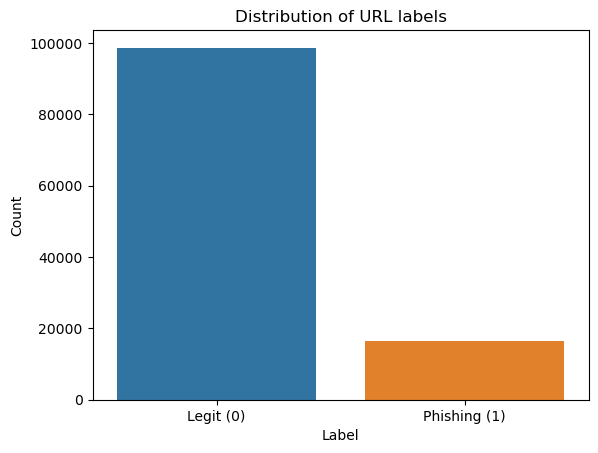

In [88]:
# Target variable = 'label'
print("Label Distribution:")
display(pd.DataFrame({
    'Count': df_filter['label'].value_counts(),
    'Proportion': df_filter['label'].value_counts(normalize=True)
}).rename(index={0:'Legit', 1:'Phishing'}))

# Plot
sns.countplot(x='label', data=df_filter, hue='label', legend=False)
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Legit (0)', 'Phishing (1)'])
plt.title('Distribution of URL labels')
plt.show()

## 📏 2.1 Length-Based

It was found that

In [89]:
# Length only features
features_len = ['url_len', 'dom_len', 'tld_len', 'path_len', 'query_len']

**1. Boxplot**

Actually is not so suitable for these data becuase some of them have heavy number of zeros.

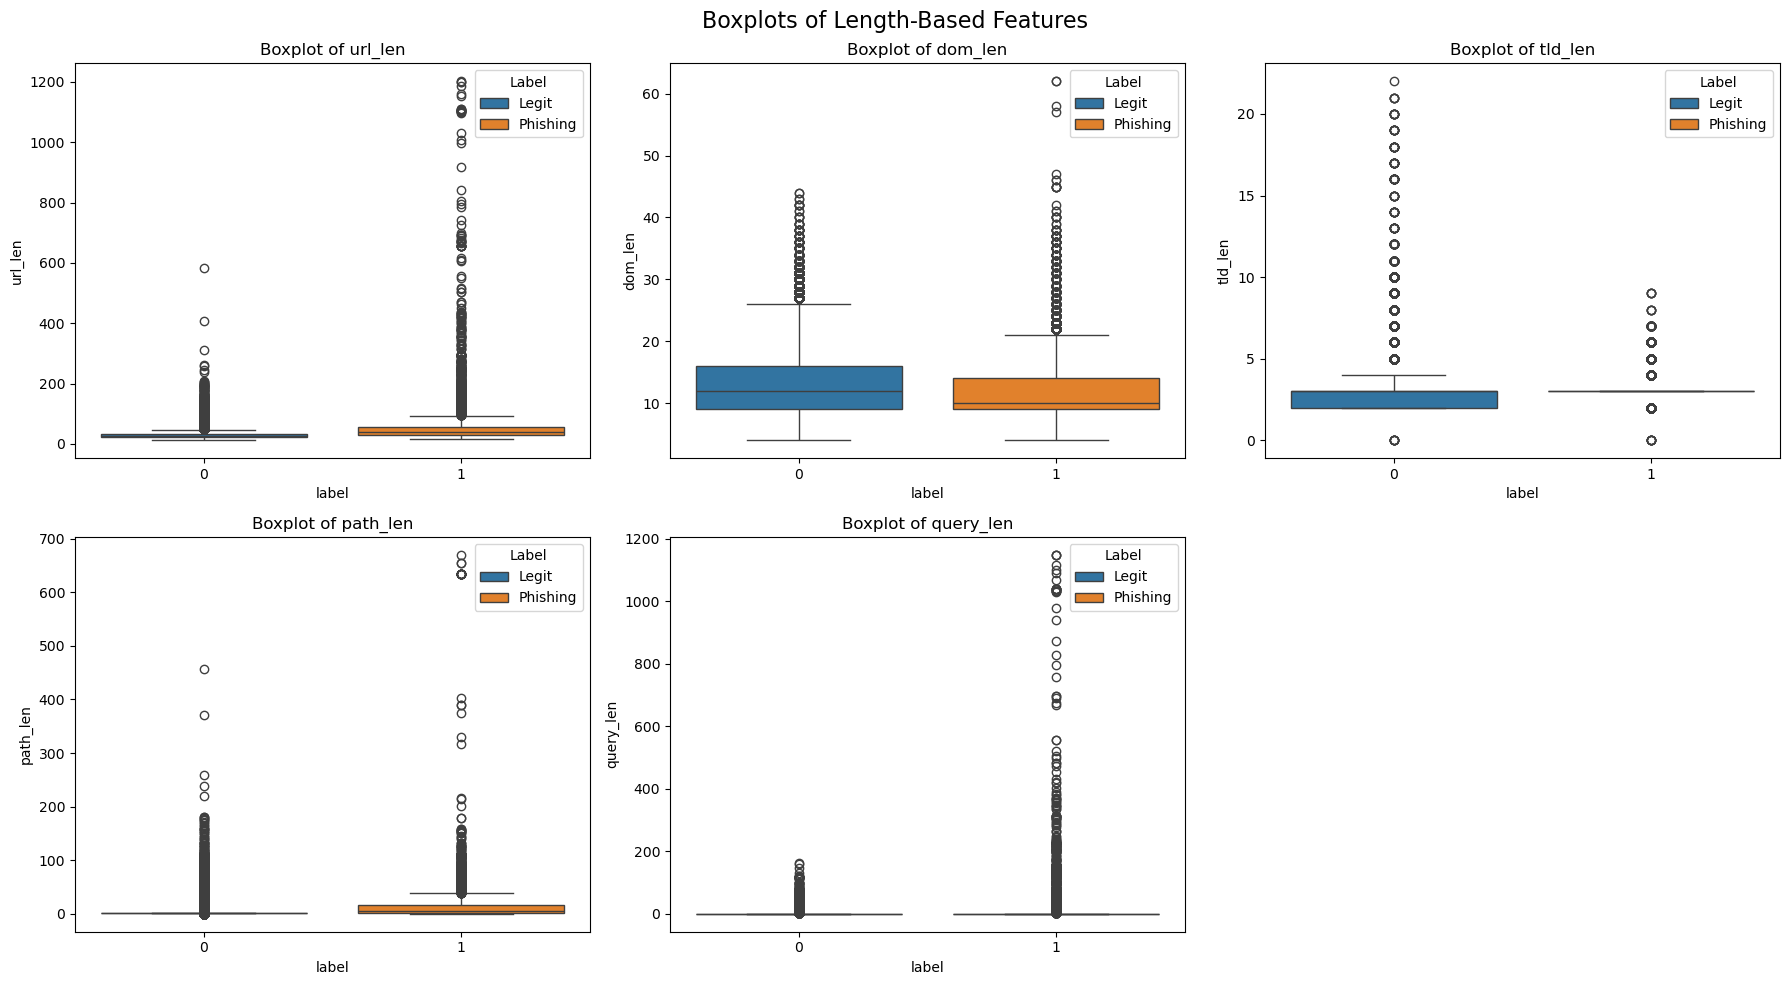

In [90]:
# Boxplots for length-based features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_len):
    sns.boxplot(data=df_filter, x='label', y=col, ax=axes[i], hue='label', hue_order=[0,1])
    axes[i].legend(title='Label', labels=['Legit', 'Phishing'], loc='upper right')
    axes[i].set_title(f'Boxplot of {col}')

# Hide the last empty subplot
axes[len(features_len)].set_visible(False)

fig.suptitle('Boxplots of Length-Based Features', fontsize=16)
plt.tight_layout()
plt.show()

**2. Using Kernel Density Estimate (KDE)**

Since the boxplot does not reveal much about the underlying distribution, use KDE with **log-transformed data**. Some of the reason to use KDE are:
  - Data is heavility zero-centered, making standard histogram hard to interpret.
  - Capture distribution nuance by producing smooth curve rather than jagged histogram.
  - Accurately portray overall spread and shape since is normalised distribution function.

> Note that natural logarithm transformation $\ln(x+1)$ was applied to each feature's value to make the distribution's shape more obvious.

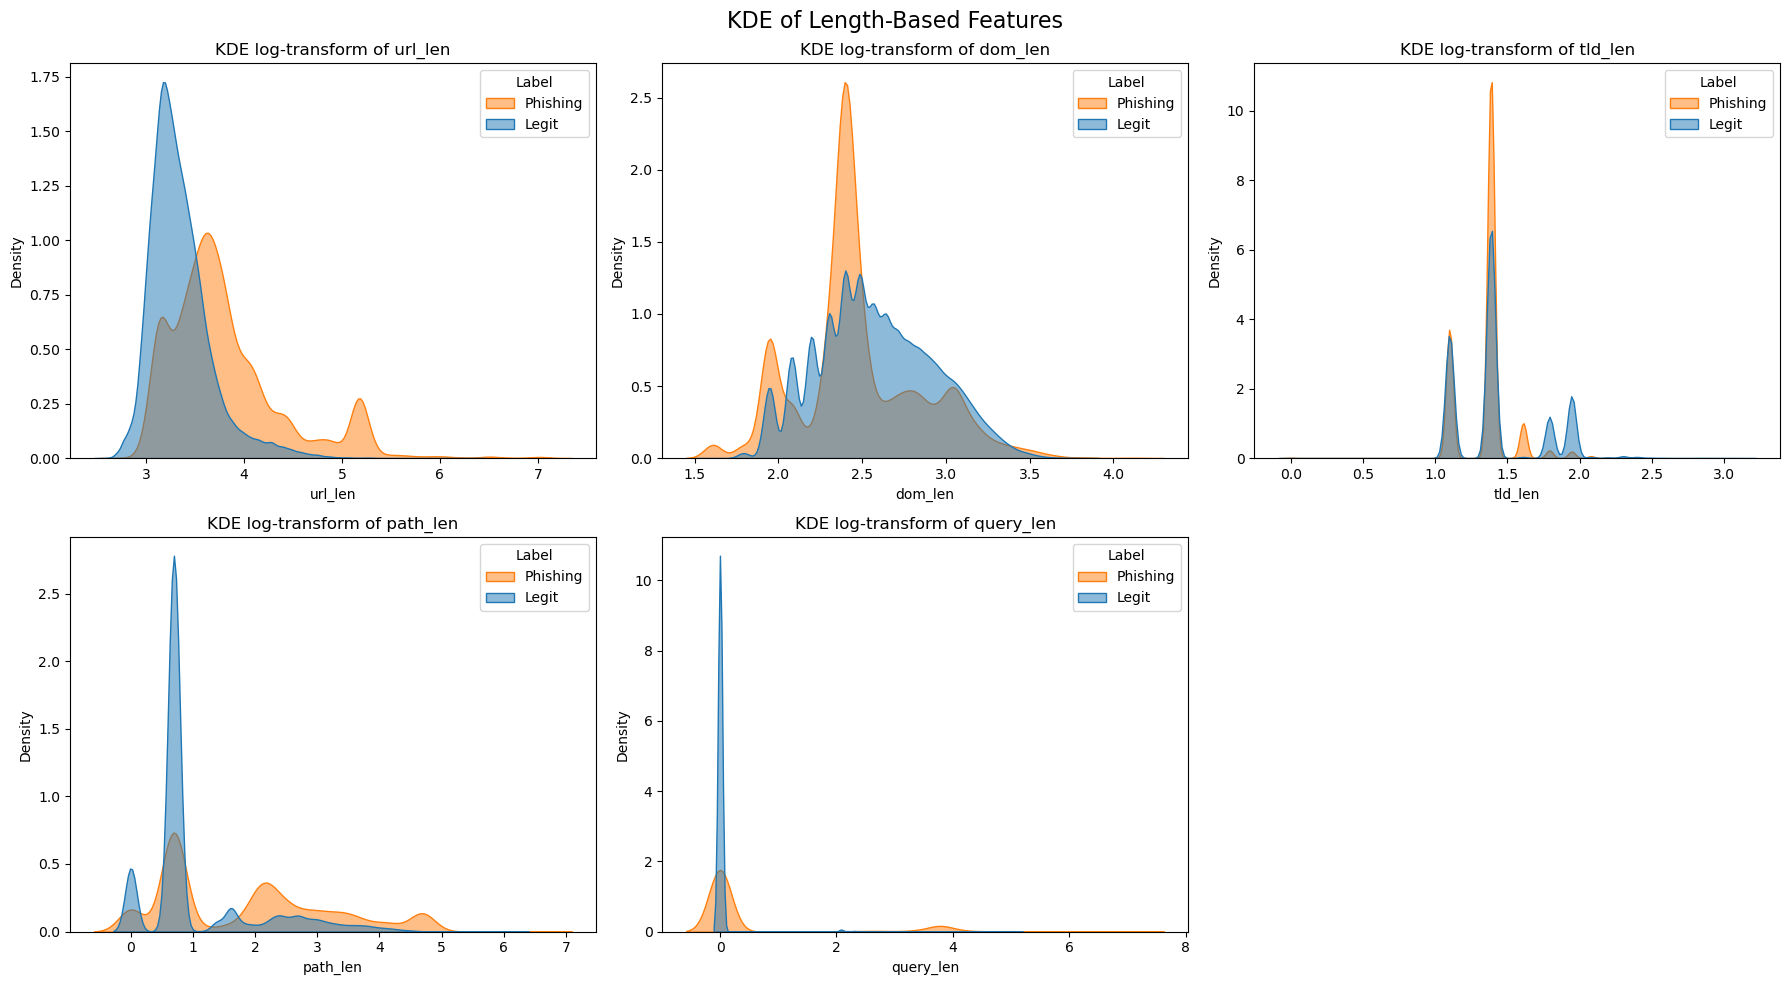

In [112]:

# KDE plots for length-based features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_len):
    # Apply log1p transformation  to handle zero values and skewness
    data_log1p = np.log1p(df_filter[col])
    
    sns.kdeplot(x=data_log1p, hue=df_filter['label'], hue_order=[0, 1], ax=axes[i], 
                fill=True, alpha=0.5, common_norm=False, warn_singular=False)
    axes[i].legend(title='Label', labels=['Phishing', 'Legit'], loc='upper right')
    axes[i].set_title(f'KDE log-transform of {col}')
    
    
# Hide the last empty subplot
axes[-1].set_visible(False)

fig.suptitle('KDE of Length-Based Features', fontsize=16)
plt.tight_layout()
plt.show()

**3. Count-Threshold Based Analysis**

Examines how the proportions of URLs  changes as  **feature counts exceed increasing thresholds** (e.g. =0, >0, >1, >2 and so on). This approach is more suitable to obtain a better visualisation because majority of raw counts in this dataset are zero (=0) and very few are larger than zero (>0), making it hard to see the underlying trends. 

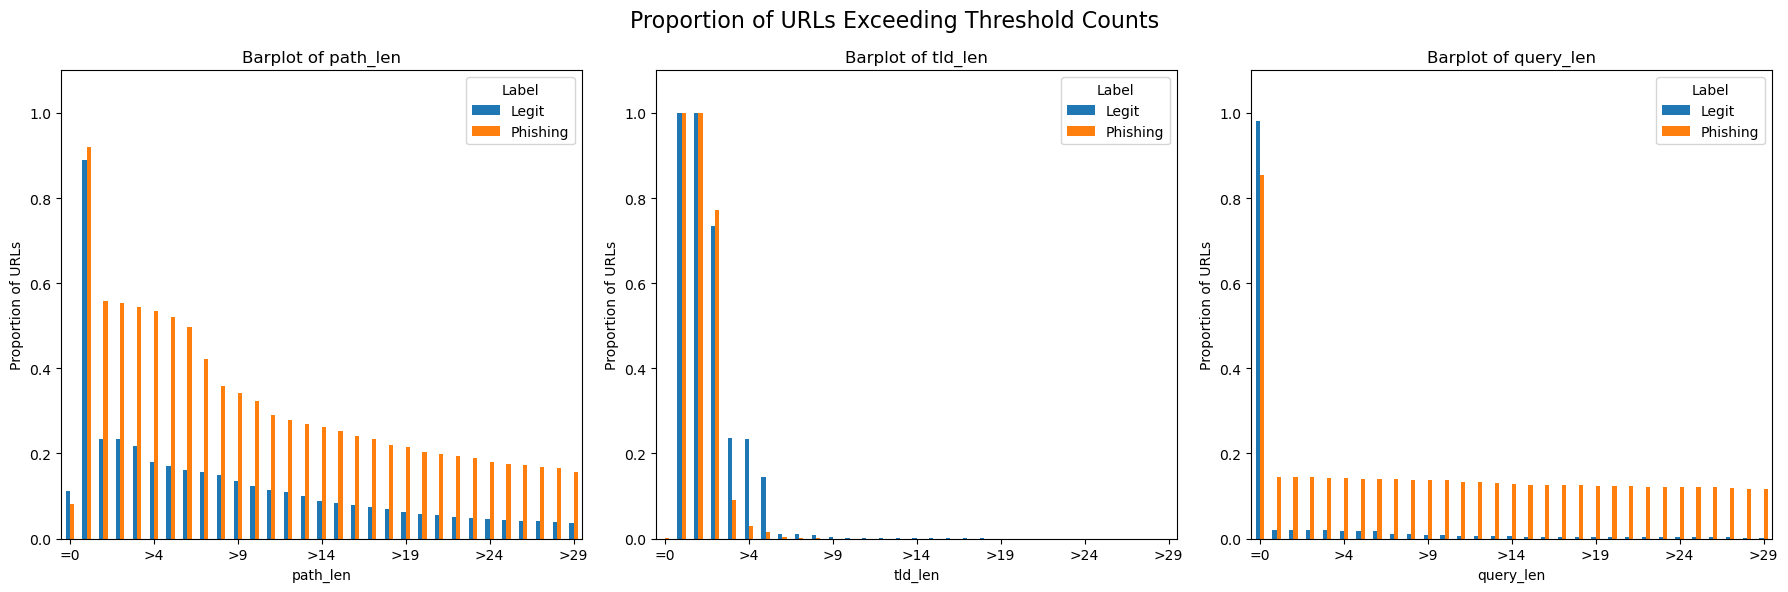

In [92]:
# Bar plot with selective x-axis labels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

features_len_check = ['path_len', 'tld_len', 'query_len']
thresholds = range(30)  # Keep all 30 thresholds

# Plot loop
for i, col in enumerate(features_len_check):
    # Build dataframe directly
    bar_df = pd.DataFrame()
    # =0 case
    bar_df['=0'] = (df_filter[col] == 0).groupby(df_filter['label']).mean()
    # thresholds
    for t in thresholds: 
        bar_df[f'>{t}'] = (df_filter[col] > t).groupby(df_filter['label']).mean()
    bar_df = bar_df.T

    # Plot
    ax = axes[i]
    bar_df.plot(kind='bar', ax=ax)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel(col)
    ax.set_ylabel("Proportion of URLs")
    ax.legend(title='Label', labels=["Legit", "Phishing"])
    
    # Show only every 5th label on x-axis
    ticks_to_show = range(0, len(bar_df), 5)  # Shows: 0, 5, 10, 15, 20, 25, 30
    labels_to_show = [bar_df.index[j] for j in ticks_to_show]
    ax.set_xticks(ticks_to_show)
    ax.set_xticklabels(labels_to_show, rotation=0)
    ax.set_title(f'Barplot of {col}')
    

# Title + layout
fig.suptitle("Proportion of URLs Exceeding Threshold Counts", fontsize=16)
plt.tight_layout()
plt.show()

In [93]:
# Simple mean comparison table
mean_comparison = pd.DataFrame()

for col in features_len:
    mean_comparison.loc['Legit', col] = df_filter[df_filter['label']==0][col].mean()
    mean_comparison.loc['Phishing', col] = df_filter[df_filter['label']==1][col].mean()

print("Mean Comparison by Label")
display(mean_comparison)

# Summary statistics by label
# for col in features_len:
#     print(f"\n--- {col} ---")
#     display(df_filter.groupby('label')[col].describe())

Mean Comparison by Label


,url_len,dom_len,tld_len,path_len,query_len
Legit,29.103365,13.023540,3.391034,4.621273,0.311088
Phishing,56.311875,11.844002,2.911272,17.163110,9.385353


## 🧮 2.2 Character Composition Features

In [94]:
# Length only features
features_char = ['letter_cnt', 'digit_cnt', 'special_cnt', 'letter_ratio', 'digit_ratio', 'spec_ratio']

**1. Boxplot**

Suitable for ratio, but not so much for counts because of heavy number of zeros.

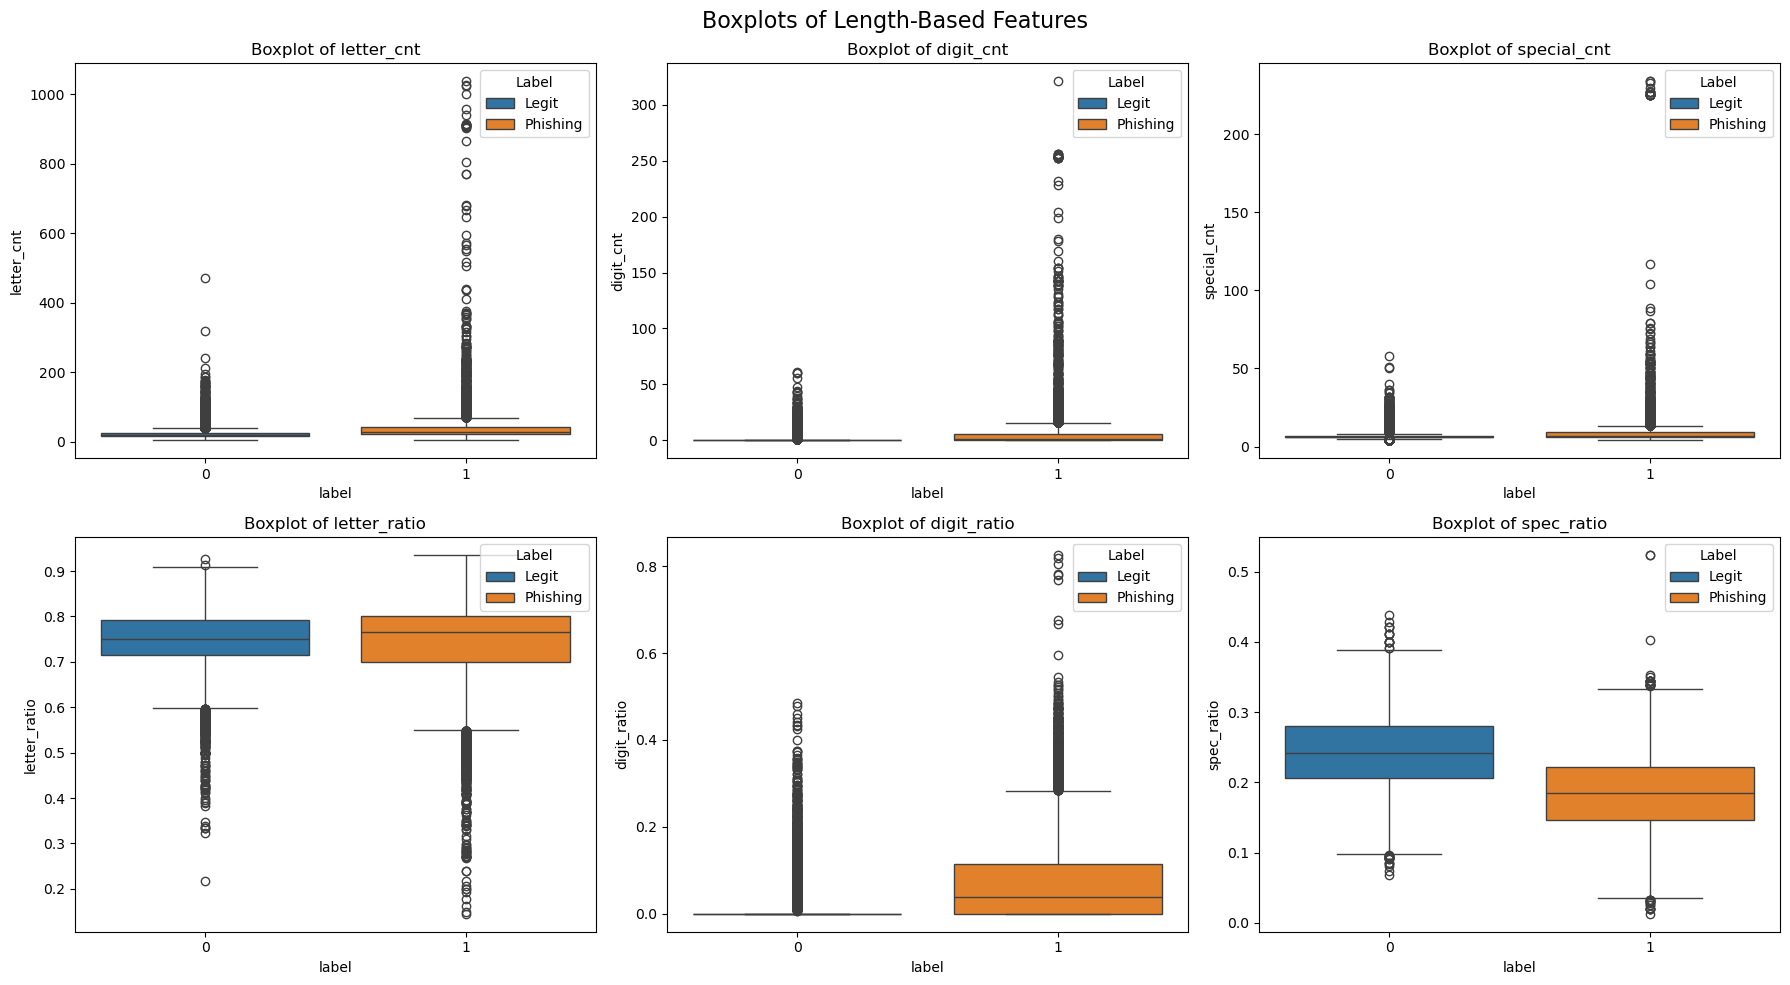

In [95]:
# Boxplots for length-based features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_char):
    sns.boxplot(data=df_filter, x='label', y=col, ax=axes[i], hue='label', hue_order=[0,1])
    axes[i].legend(title='Label', labels=['Legit', 'Phishing'], loc='upper right')
    axes[i].set_title(f'Boxplot of {col}')

fig.suptitle('Boxplots of Length-Based Features', fontsize=16)
plt.tight_layout()
plt.show()

**2. Using Kernel Density Estimate (KDE)**

Used **log-transformed KDE for raw counts**  whiile **normal KDE for ratios**.

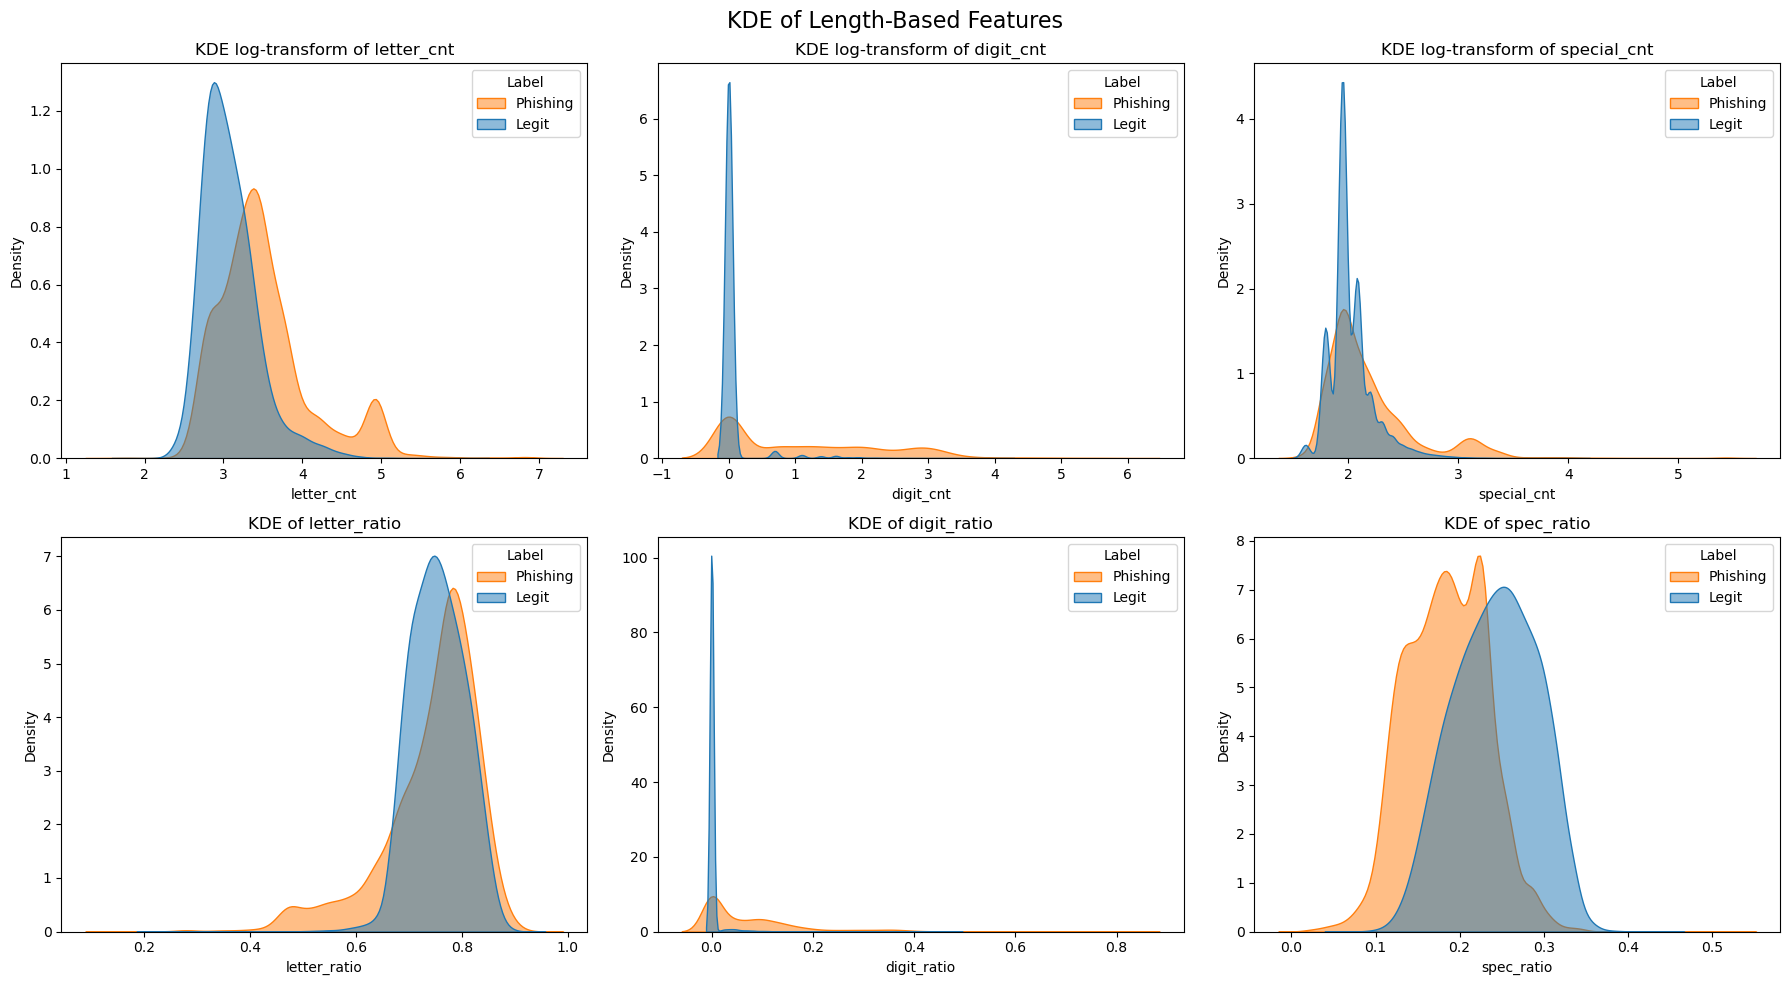

In [120]:
# KDE plots for length-based features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_char):
    # Apply log1p transformation  to handle zero values and skewness
    if i < 3: 
        data_to_plot = np.log1p(df_filter[col])
        axes[i].set_title(f'KDE log-transform of {col}')
    else: 
        data_to_plot = df_filter[col] # ratio no need log transform
        axes[i].set_title(f'KDE of {col}')
    
    sns.kdeplot(x=data_to_plot, hue=df_filter['label'], hue_order=[0, 1], ax=axes[i], 
                fill=True, alpha=0.5, common_norm=False, warn_singular=False, bw_method=0.2)
    axes[i].legend(title='Label', labels=['Phishing', 'Legit'], loc='upper right')

fig.suptitle('KDE of Length-Based Features', fontsize=16)
plt.tight_layout()
plt.show()

Summary, for raw counts of letter and special character counts for phishing URLs tend to be higher than legitimate. However, it seems to be the opposite for ratios of letter and special character, where phishing URLs tend to have lower ratio than legitimate URLs. Interestingly, for digits it seems that both raw counts and ratio produce similar trends. The phishing URLs is seen to have much broader tails while legitimate URLs tend to cluster at 0. This strongly indicates that if the URL contains digits, then it is likely to be phishing.


**1. `letter_cnt`**

Legitimate URLs have unimodal distribution peaking at approximately 3 (~19.09 counts), while phishing URLs is bimodal with peaks at approximately 3.5 (~32.12 counts) and 5 (~147.41 counts). Distribution for phishing is also more heavily right-skewed compared to legitimate. Overall, phishing URLs have longer letter counts than legitimate URLs.


**2. `digit_cnt`**

Both legitimate and phishing URLs are unimodal distributions, peaking at 0 (~0 counts). However, distribution for legitimate is almost completely clustered at 0, whereas phishing has a much broader right-skewed tail. Overall, phishing URLS have highier digit count compared to legitimate URLs.


**3. `special_cnt`**

Distribution for legitimate URLs peaks at approximately 2 (~6.39 counts), whereas phishing URLs is bimodal with peaks at approximately 2 (~6.39 counts) and 3.1 (~21.20 counts). However, distribution for phishing is more heavily right-skewed compared to legitimate. Overall, phishing URLs have more special characters compared to legitimate URLs.


**4. `letter_ratio`**

Both legitimate and phishing URLs have unimodal distribution peaking at about approximate 0.8 ratio and heavy overlap. However, distribution for legitimate seems to be very Gaussian whereas phishing is more left-skewed. Overall, phishing URLs tend to have shorter letter ratio compared to legitimate URLs becuase of their high url length.


**5. `digit_ratio`**

Both legitimate and phishing URLs are unimodal distributions, peaking at 0 ratio (~0 counts). However, distribution for legitimate is almost completely clustered at 0, whereas phishing has a broader right-skewed tail. Overall, phishing URLS have highier digit ratio compared to legitimate URLs.


**6. `spec_ratio`**

Legitimate URLs have unimodal distribution peaking at approximately 0.30 ratio, whereas phishing URLs seems to be bimodal with peaks at approximately 0.20 and 0.25 ratio. However, distribution for phishing is more heavily left-skewed compared to legitimate. Overall, phishing URLs tend to have shorter special character ratio compared to legitimate URLs because of their hight url length.

## ➗ 2.3 Specific Special Character Features

For the count only features, boxplot is **NOT suitable** because of high zero-inflation. _Majority of observations are clustered at 0, with sparce positive outliers_. Hence the interquartile range (IQR) of some boxplots can be difficult to read, because they are as thin as a line with very broad whiskers.

Therefore, the following analysis steps were carried out:
- Stripplot — Replaces boxplot to see raw spread
- Count-Threshold — Overcome the large amount is zeros issue

In [97]:
# Special character only features
features_special = ['eq_cnt', 'qm_cnt', 'amp_cnt', 'dot_cnt', 'dash_cnt', 'under_cnt', 'slash_cnt']

**1. Using Stripplot**

We see that there are 3 main features that have a broad and distinguishable spread: **`letter_cnt`**, **`digit_cnt`** and **`special_cnt`**, which are heavily skewed right. Meanwhile, the other features range from having _subtle_ distinguishble spread to _none_ at all. Futher investigation is necessary.

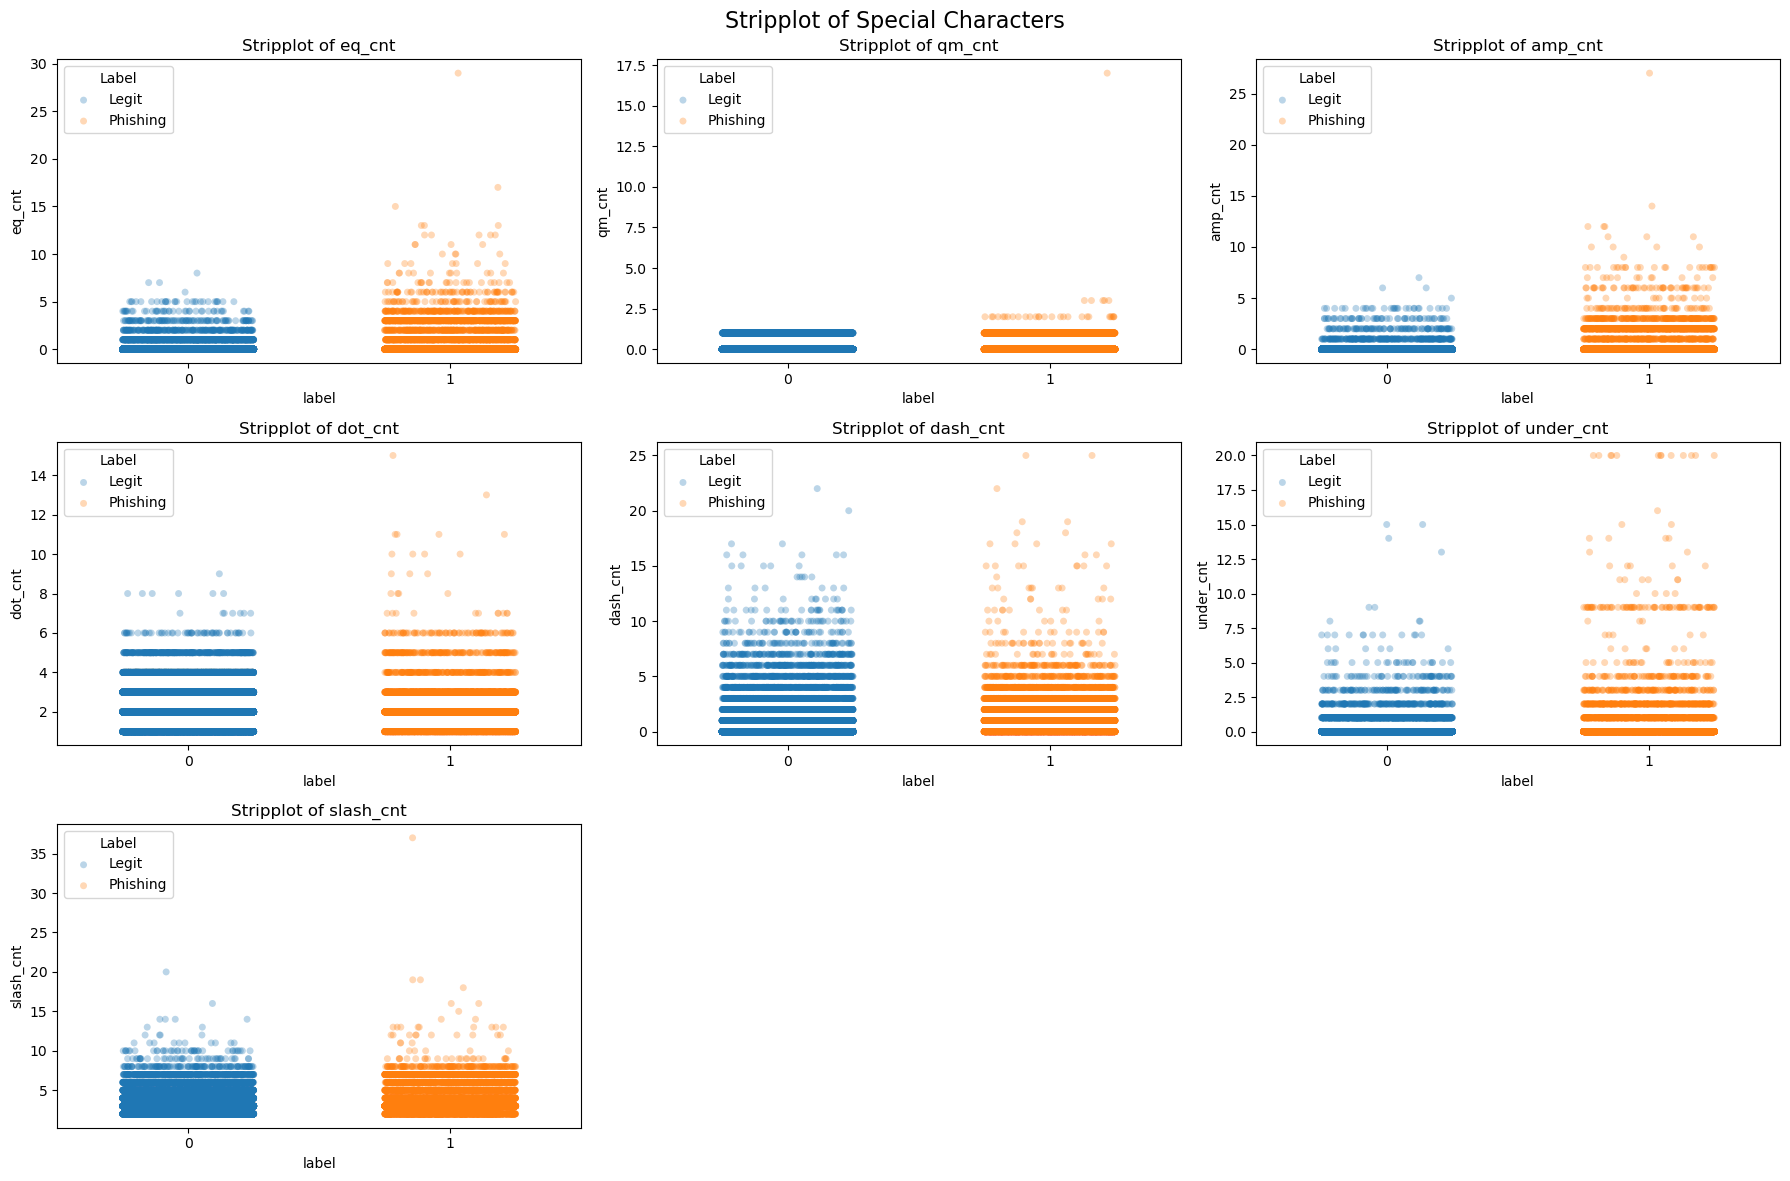

In [98]:
# Rough Distribution using Stripplot
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten() # helps looping

# Plotting in a loop
for i, col in enumerate(features_special):
  sns.stripplot(data=df_filter, x='label', y=col, ax=axes[i], jitter=0.25, hue='label', alpha=0.3)
  axes[i].legend(title='Label', labels=["Legit", "Phishing"], loc='upper left')
  axes[i].set_title(f'Stripplot of {col}')

# Hide last few empty subplot
axes[-1].set_visible(False)
axes[-2].set_visible(False)

fig.suptitle('Stripplot of Special Characters', fontsize=16)
plt.tight_layout()
plt.show()

**2. Count-Threshold Based Analysis**

Proportion of phishing URLs is generally larger compared to the legitimate URLs for features **`dash_cnt`**, **`slash_cnt`**, **`eq_cnt`**,**`qm_cnt`**, **`amp_cnt`** and **`under_cnt`**. However, analysing **`dot_cnt`** we notice that as the vount increases, proportion of legitimate URLs is actually larger than phishing.

 > Notably, **`qm_cnt`** seems to only have a single threshold (>0), with the rest (>1, >2, etc) being zero. This makes sense because there can only be one question mark `?` in URL since it denotes a query.

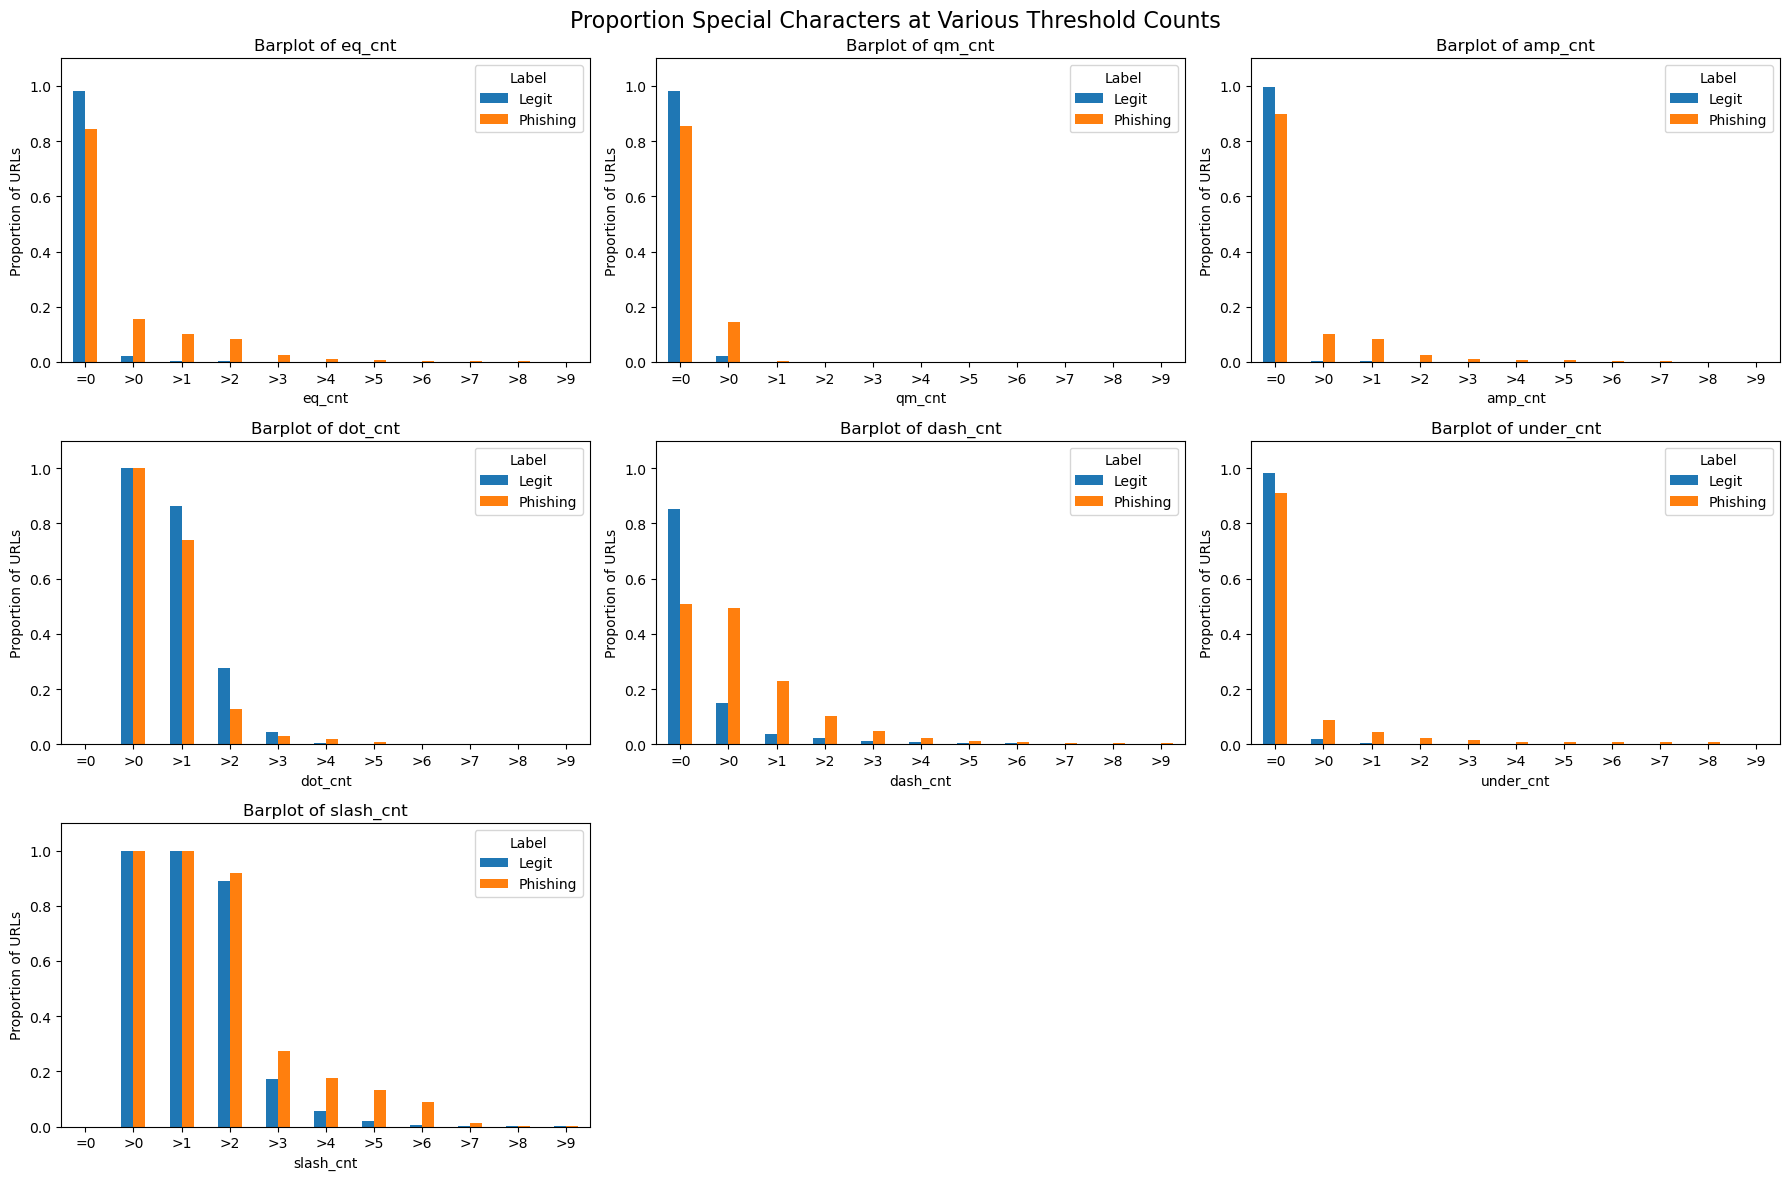

In [99]:
# Bar plot
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

thresholds = range(10)  # 0-7

# Plot loop
for i, col in enumerate(features_special):
    # Build dataframe directly
    bar_df = pd.DataFrame()
    # =0 case
    bar_df['=0'] = (df_filter[col] == 0).groupby(df_filter['label']).mean()
    # thresholds
    for t in thresholds: 
        bar_df[f'>{t}'] = (df_filter[col] > t).groupby(df_filter['label']).mean()
    bar_df = bar_df.T

    # Plot
    bar_df.plot(kind='bar', ax=axes[i])
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Proportion of URLs")
    axes[i].legend(title='Label', labels=["Legit", "Phishing"])
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].set_title(f'Barplot of {col}')

# Hide unused subplot
axes[-1].set_visible(False)
axes[-2].set_visible(False)

# Title + layout
fig.suptitle("Proportion Special Characters at Various Threshold Counts", fontsize=16)
plt.tight_layout()
plt.show()

Overall, it is clear from the various graphs (with the exception of `dot_cnt`) that a higher number of special characters seem to suggest phishing. 

**1. `eq_cnt`**

From the bar plot, almost 100% of legitimate URLs and approximately 80% of phishing URLs have 0 counts (i.e. at threshold =0). However, beyond zero (>0, >1, etc.), phishing consistently show higher proportions compared to legitimate. This makes sense because (`=`) are commonly used in query strings to structure parameters, which are used by attackers. Overall, URLs containing equals sign character (`=`) is a good indicator of phishing URLs. 


**2. `qm_cnt`**

From the bar plot, almost 100% of legitimate URLs and approximately 80% of phishing URLs have 0 counts (i.e. at threshold =0). Interestingly, comparing the proportion of zero counts (=0) of question mark character (`?`) with equals sign character (`=`), we find that they are identical. This makes sense because (`?`) start a URL query while (`=`) assigns variable to the query, hence they always comes in pairs. Another interesting finding is that, there is never more than a single (`?`) in this dataset. Overall, URLs containing question marks (`?`) is a strong indicator of phishing.


**3. `amp_cnt`**

From the bar plot, almost 100% of legitimate URLs and approximately 90% of phishing URLs have 0 counts (i.e. at threshold =0). However, beyond zero (>0, >1, etc.), phishing consistenly show higher proportions compared to legitimate. This makes sense because the role of ampersand character (`&`) is to seperate multiple key-value pairs within same query string (`?`) as discussed previously. Overall, URLs containing ampersand sign character (`=&) is a good indicator of phishing URLs. 

**4. `dot_cnt`**

From the bar plot, it was observed that the proportion of legitimate URLs tend to be larger compared to phishing URLs as the number of dot characters (`.`) increase. This overlap makes it challenging to reliably distinguish phishing URLs from legitimate ones.


**5. `dash_cnt`**

From the bar plot, it was observed that the proportion of phishing URLs with more-than-one (i.e. at threshold >0, >1, etc.) dash character (`-`)  is much higher compared to legitimate URLs. This strongly suggests that URLs that have dashes (`-`) are likely phishing.


**6. `under_cnt`**

From the bar plot, almost 100% of legitimate URLs and approximately 90% of phishing URLs have 0 counts (i.e. at threshold =0). However, beyond zero (>0, >1, etc.), phishing consistently show higher proportions compared to legitimate. This makes sense because underscore character (`_`) is not commonly used in website names. Overall, URLs containing underscore character (`_`) is a strong indicator of phishing.


**7. `slash_cnt`**

From the bar plot, it was observed that the proportion of phishing URLs with more-than-four (i.e. at thresholds >3, >4, etc.) slash character (`/`)  is higher compared to legitimate URLs. This strongly suggests that URLs with large number of slashes (`/`) are likely to be phishing.

## ⭕ 2.4 Structural and Hierarchical Features

There is very few `is_ip`, therefore may be unreliable.

In [100]:
# Structural features
features_structural = ['subdom_cnt', 'is_ip']

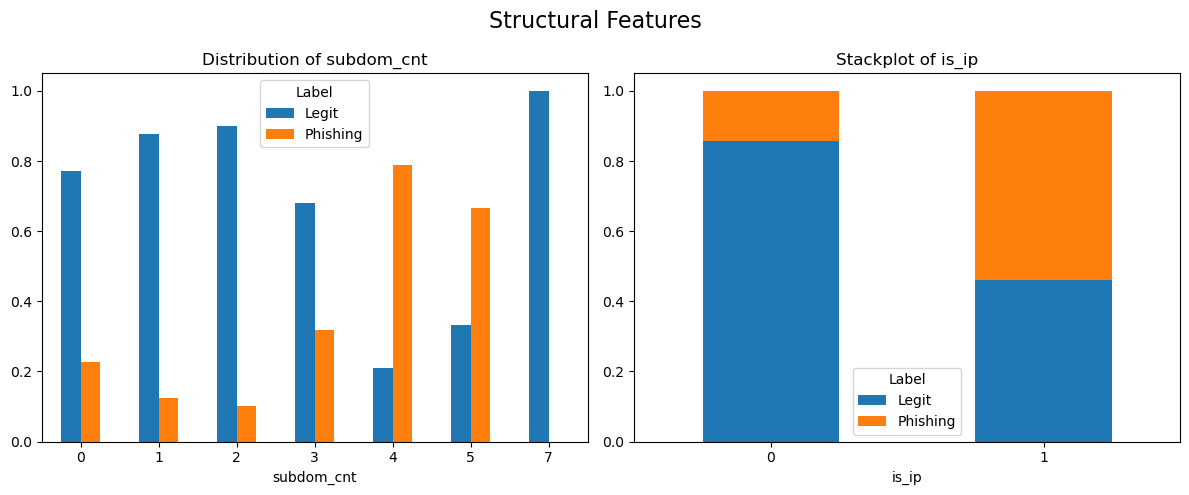

In [101]:
# Structural Features - Mixed Plot Types
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First feature: subdom_cnt - side by side
pd.crosstab(df_filter['label'], df_filter['subdom_cnt'], normalize='columns').T.plot(kind='bar', stacked=False, ax=axes[0], rot=0)
axes[0].set_title('Distribution of subdom_cnt')
axes[0].legend(title='Label', labels=["Legit", "Phishing"])

# Second feature: is_ip - stacked
pd.crosstab(df_filter['label'], df_filter['is_ip'], normalize='columns').T.plot(kind='bar', stacked=True, ax=axes[1], rot=0)
axes[1].set_title('Stackplot of is_ip')
axes[1].legend(title='Label', labels=["Legit", "Phishing"])

plt.suptitle('Structural Features', fontsize=16)
plt.tight_layout()
plt.show()

In [102]:
# Mean of subdomain count
print(f"Mean subdom_cnt: {df_filter['subdom_cnt'].mean():.2f}")

# Count and proportion for URL with IP
is_ip_summary = pd.DataFrame()
is_ip_summary.loc['Count', 'is_ip = 0'] = (df_filter['is_ip'] == 0).sum()
is_ip_summary.loc['Count', 'is_ip = 1'] = (df_filter['is_ip'] == 1).sum()
is_ip_summary.loc['Proportion', 'is_ip = 0'] = (df_filter['is_ip'] == 0).mean()
is_ip_summary.loc['Proportion', 'is_ip = 1'] = (df_filter['is_ip'] == 1).mean()

print("\nSummary of URLs with IP Address")
display(is_ip_summary)

Mean subdom_cnt: 0.84

Summary of URLs with IP Address


,is_ip = 0,is_ip = 1
Count,115218.000000,13.000000
Proportion,0.999887,0.000113


**`subdom_cnt`**

From the barplot, it was observed that URLs with 4 or 5 subdomains (e.g. `.www`) have much higher likelihood to be phishing, meanwhile, all other number of subdomain have higher proportion to be legitimate. Overall, the number of subdomains alone is probably not a strong feature to indicate phishing because there are no distingushing indicators.


**`is_ip`**

URLs containing IP addresses exhibit a higher proportion of phishing cases, suggesting that attackers often bypass domain registration to reduce traceability and detection.

## 🛡️ 2.5 Protocol and Security Indicator

In [103]:
# Binary only features
features_protocol = ['is_https']

# Probability of phishing given is_https = 1
prob = df_filter[df_filter['is_https'] == 1]['label'].mean()
print(f"P(phishing | {col}=1) = {prob:.3f} ({prob*100:.1f}%)")

P(phishing | slash_cnt=1) = 0.306 (30.6%)


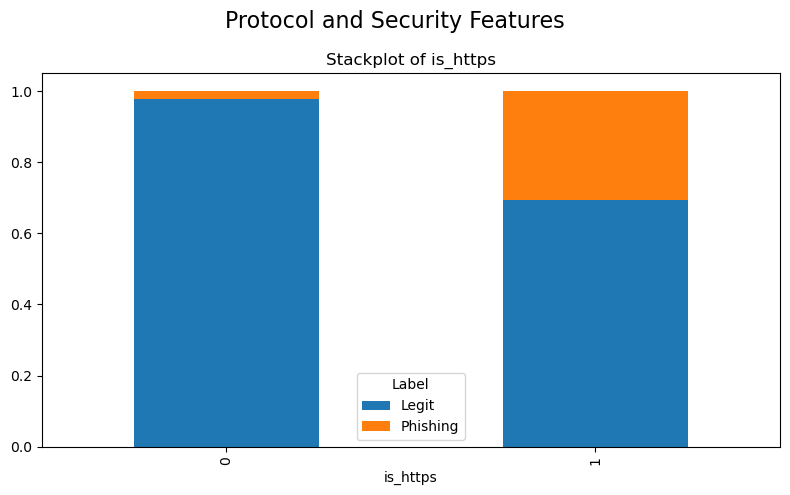

In [104]:
# Structural Features - is_ip Stacked Bar Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# is_https - stacked
pd.crosstab(df_filter['label'], df_filter['is_https'], normalize='columns').T.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Stackplot of is_https')
ax.legend(title='Label', labels=["Legit", "Phishing"])

plt.suptitle('Protocol and Security Features', fontsize=16)
plt.tight_layout()
plt.show()

**`is_https`**

The presence of HTTPS does not strongly differentiate phishing from legitimate URLs, as phishing sites increasingly adopt HTTPS to mimic secure and trustworthy websites.

## 🌡️ 2.6. Shanon Entropy

### Theory

Given a discrete random variable $X$ over an alphabet $\mathcal{A}$ with probability mass function $P(X=x_i)=p_i$, the **Shanon entropy** is:
$$
H(X)=-\sum_{i=1}^n p_i\log_2p_i
$$

For a string $s$ of length $N$ over alphabet $\mathcal{A}$, the formula for probability $p_i$ of seeing character $c_i$ is:
$$
p_i=\frac{\mathrm{count}(c_i,s)}{N},\qquad \forall c_i\in\mathcal{A}
$$

Therefore, the full formula for Shanon entropy applied to a string is:
$$
H(s)=-\sum_{c_i\in\mathcal{A}}\frac{\mathrm{count}(c_i,s)}{N}\cdot \log_2\left(\frac{\mathrm{count}(c_i,s)}{N}\right)
$$

Invariant rule:
$$
0\leq H(s)\leq \log_2\left|\mathcal{A}\right|
$$

> Note that these are **empirical frequencies**, the string's character distribution is used as the probability model. Meaning, this is the most fundamental form of entropy that solely depends on the number of occurrences of a character within a particular string, it does NOT use the known probability of a character appearing in English langauge (i.e. Cross Entropy).

### Code

In [105]:
# Entropy only features
features_entropy = ['entropy']

# Mean entropy
print(f"Mean entropy for Legit: {df_filter[df_filter['label']==0]['entropy'].mean():.3f}")
print(f"Mean entropy for Phishing: {df_filter[df_filter['label']==1]['entropy'].mean():.3f}")

# Arbitrary threshold for high_entropy
high_entropy = 4.0

# Confusion matrix 
print('\n--- Confusion Matrix ---')
crosstab = pd.crosstab(df_filter['entropy'] > high_entropy, df_filter['label'], normalize='index')
crosstab.index = ['low_entropy', 'high_entropy']
crosstab.columns = ['legit', 'phishing']
display(crosstab)

# True counts
print('\n--- True Counts ---')
counts = pd.crosstab(df_filter['entropy'] > high_entropy, df_filter['label'])
counts.index = ['low_entropy', 'high_entropy']
counts.columns = ['legit', 'phishing']
display(counts)

# Probability 
print('\n--- Probability of Phishing given High Entropy ---\n')
prob = df_filter[df_filter['entropy'] > high_entropy]['label'].mean()
print(f"P(phishing | entropy > {high_entropy}) = {prob:.3f}")

Mean entropy for Legit: 3.789
Mean entropy for Phishing: 4.316

--- Confusion Matrix ---


,legit,phishing
low_entropy,0.948119,0.051881
high_entropy,0.623563,0.376437



--- True Counts ---


,legit,phishing
low_entropy,78253,4282
high_entropy,20388,12308



--- Probability of Phishing given High Entropy ---

P(phishing | entropy > 4.0) = 0.376


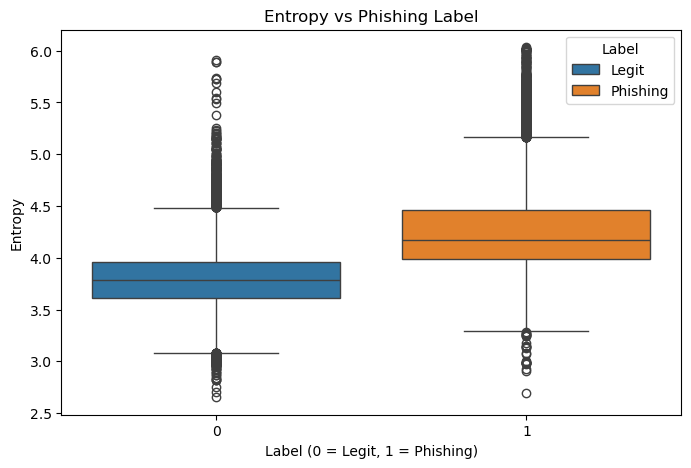

In [106]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='entropy', data=df_clean, hue='label')
plt.title("Entropy vs Phishing Label")
plt.xlabel("Label (0 = Legit, 1 = Phishing)")
plt.ylabel("Entropy")
plt.legend(title='Label', labels=["Legit", "Phishing"])
plt.show()

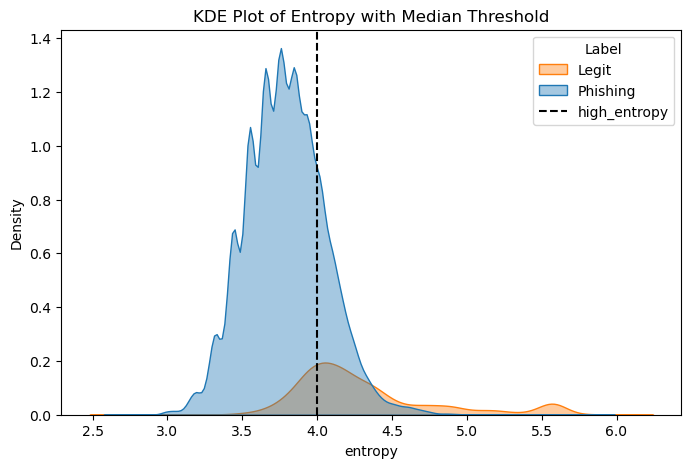

In [107]:
plt.figure(figsize=(8,5))

sns.kdeplot(data=df_filter, x='entropy', hue='label', fill=True, alpha=0.4)
plt.axvline(4.0, color='black', linestyle='--', label='high_entropy')

plt.title("KDE Plot of Entropy with Median Threshold")
plt.legend(title="Label", labels=["Legit", "Phishing", "high_entropy"])
plt.show()

---

# 📉 3.  Correlation Matrix & Feature Checker

Further analysis in the following sections will determine which features to be dropped.
- Normally two features such as `url_len` and `letter_ratio` have high correlation because one is a subset on the other.
- We cannot simply remove either one of the features because their meaning meaning has transformed somewhat.
- To determine whether to keep or remove such features, need to investigate using statistics or plotting relavant graphs.



In [108]:
from sklearn.ensemble import RandomForestClassifier

# Calculate correlations with target variable 'label'
correlations = df_filter.corr(numeric_only=True)['label'].abs().sort_values(ascending=False)

# Random forest feature importance
X = df_filter.drop(columns=['label'])
y = df_filter['label']
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Combine into one DataFrame - DROP 'label' from correlations FIRST
correlations_without_label = correlations.drop('label')

# Now all columns have the same index
comparison_table = pd.DataFrame({
    'Feature': correlations_without_label.index,
    'Correlation coefficient': correlations_without_label.values,
    'RF_Importance (Normalised)': rf_importance.reindex(correlations_without_label.index).values
})

print("\nFeature Importance Comparison")
print("-" * 65)
print(comparison_table.to_string(index=False))
print("-" * 65)


Feature Importance Comparison
-----------------------------------------------------------------
     Feature  Correlation coefficient  RF_Importance (Normalised)
 digit_ratio                 0.517661                    0.108146
     entropy                 0.513368                    0.136374
    is_https                 0.400466                    0.153889
  spec_ratio                 0.385275                    0.053586
   digit_cnt                 0.329212                    0.065007
     url_len                 0.323547                    0.056323
  letter_cnt                 0.300636                    0.047336
      eq_cnt                 0.261119                    0.001772
    path_len                 0.249139                    0.071624
    dash_cnt                 0.247773                    0.032228
      qm_cnt                 0.225656                    0.000858
     amp_cnt                 0.224631                    0.000456
 special_cnt                 0.203040        

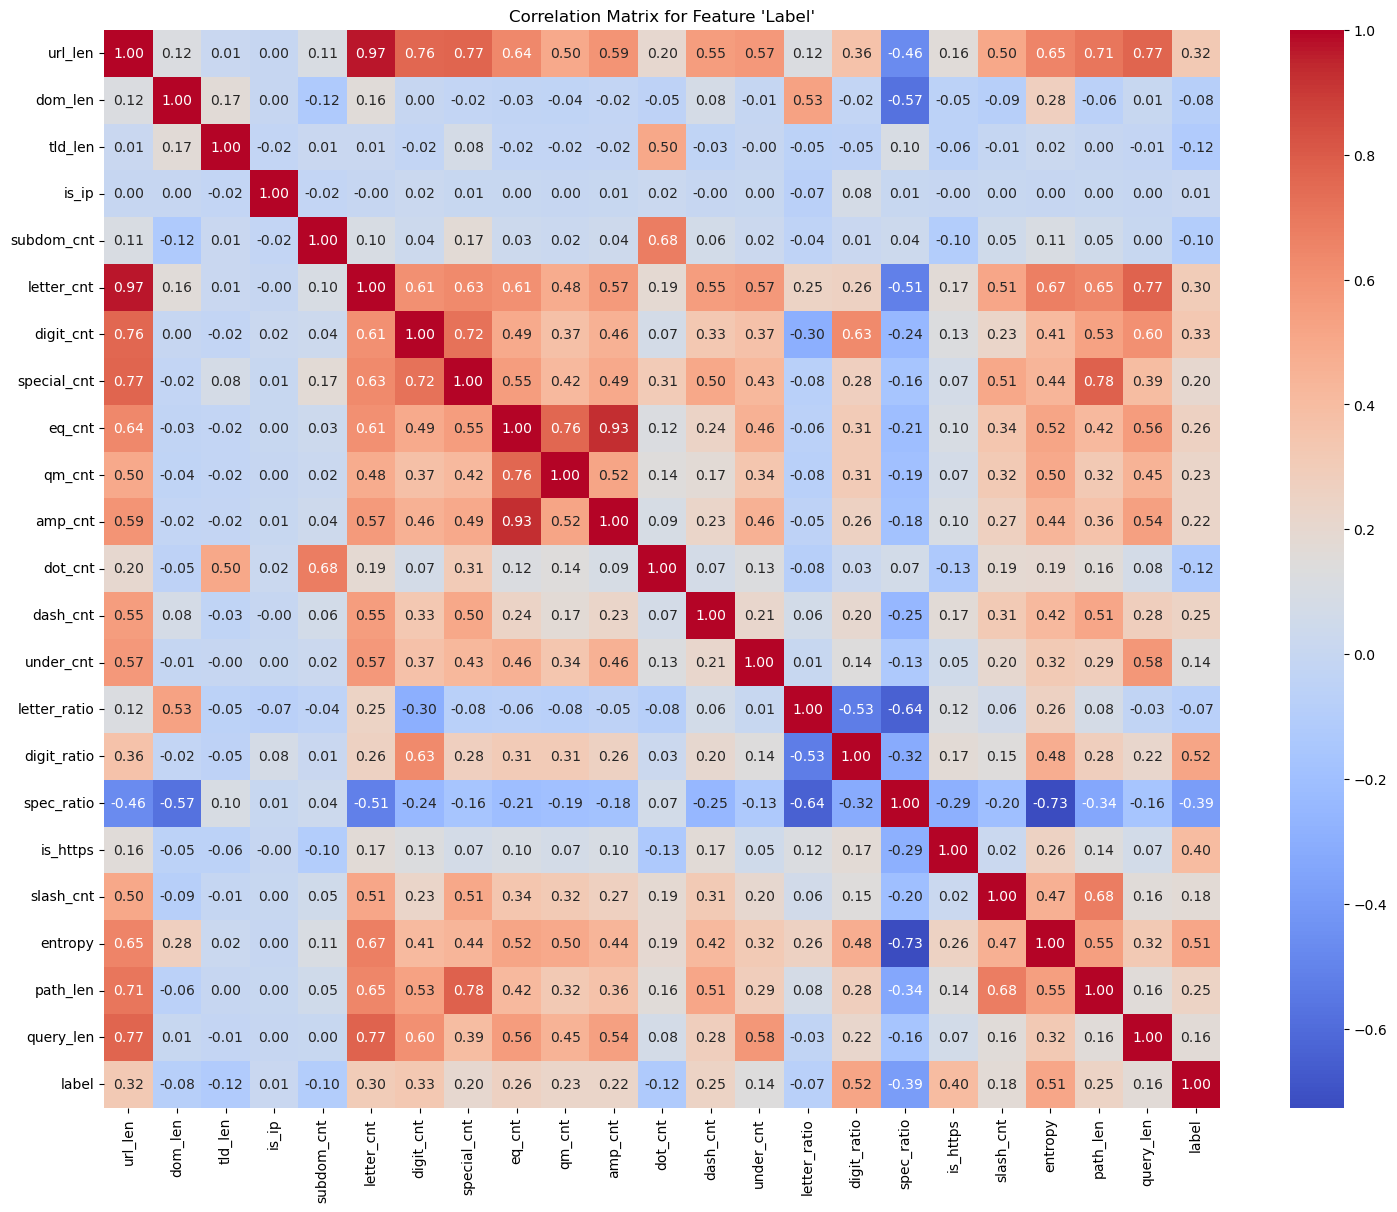

In [109]:
# Plot correlation heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(df_filter.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix for Feature 'Label'")
plt.show()

- Use Random forest to visualise important features and compare with correlation.

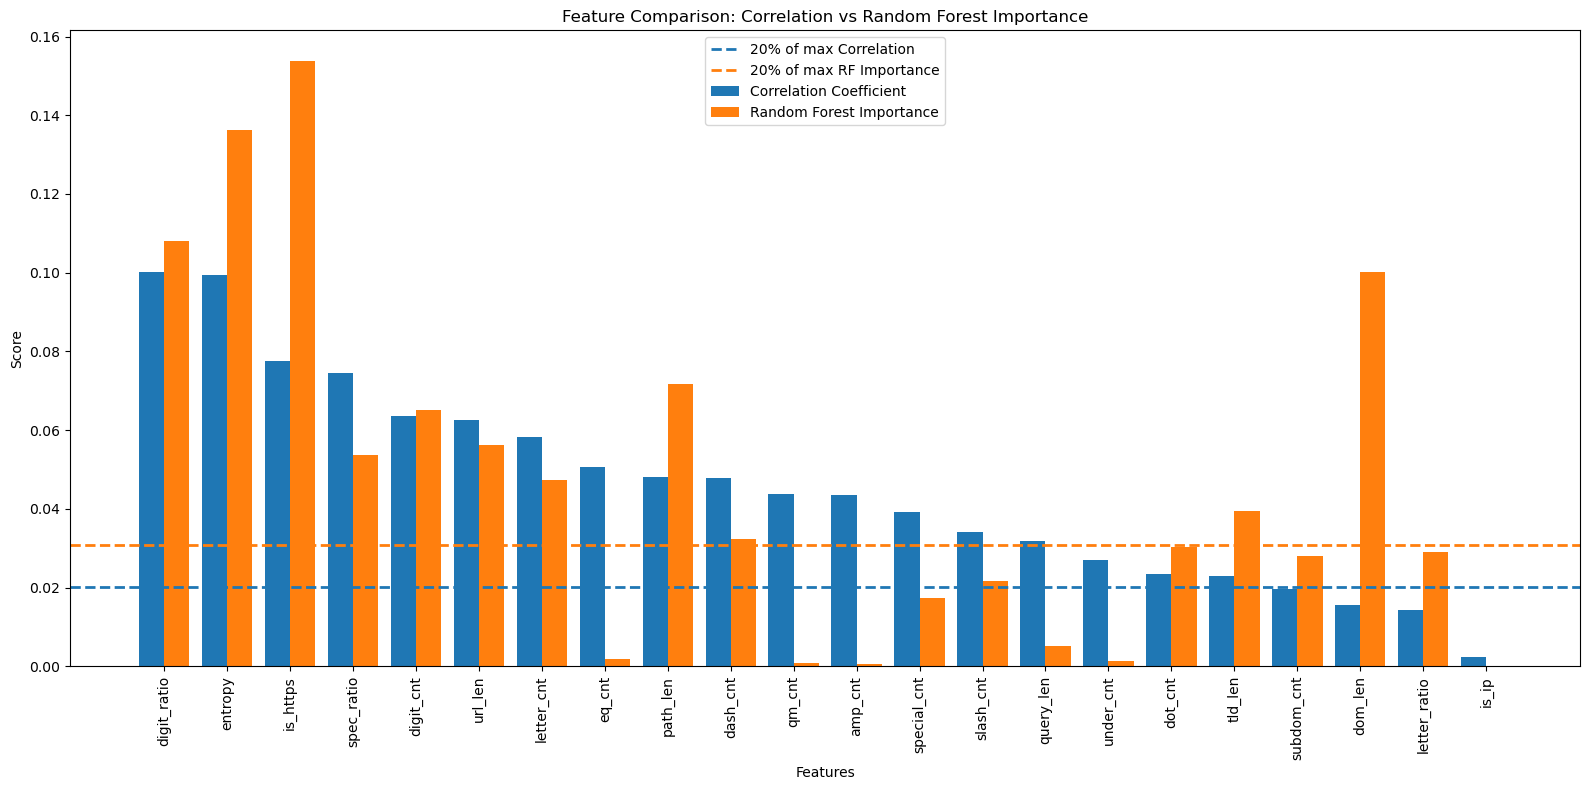

In [110]:
# Remove target itself from correlation list
correlations_without_label = correlations.drop('label')

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Feature': correlations_without_label.index,
    'Correlation_Normalised': correlations_without_label.values / correlations_without_label.sum(),
    'RF_Importance': rf_importance.reindex(correlations_without_label.index).fillna(0).values
})

# Plot
plt.figure(figsize=(16,8))
bar_width = 0.4
indices = np.arange(len(comparison_df))

# Bar graph
plt.bar(indices - bar_width/2, comparison_df['Correlation_Normalised'], width=bar_width, label='Correlation Coefficient')
plt.bar(indices + bar_width/2, comparison_df['RF_Importance'], width=bar_width, label='Random Forest Importance')

# Dotted horizontal line (20% of maximum feature importance)
threshold_co = comparison_df['Correlation_Normalised'].max() * 0.2
threshold_rf = comparison_df['RF_Importance'].max() * 0.2

plt.axhline(y=threshold_co, color='C0', linestyle='--', linewidth=2, label='20% of max Correlation')
plt.axhline(y=threshold_rf, color='C1', linestyle='--', linewidth=2, label='20% of max RF Importance')

plt.xticks(indices, comparison_df['Feature'], rotation=90)
plt.xlabel('Features')
plt.ylabel('Score')
plt.title('Feature Comparison: Correlation vs Random Forest Importance')
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()

---

# IMPORTANT AI

The Architecture: Two Feature Matrices

You will start with your base dataframe containing the engineered binary flags (has_eq, has_amp, etc.) and the raw counts (letter_cnt, subdom_cnt, etc.). From there, split your pipeline:
Pipeline A: The Tree Space (X_tree)

(For XGBoost, Random Forest, LightGBM)

    Transformations: None.

    Mechanism: Feed the raw counts and binary flags directly.

    Trade-off: This maintains perfect interpretability. When you generate feature importance scores or SHAP values later, "number of letters > 50" is much easier to explain to stakeholders than "log(number of letters) > 3.9".

Pipeline B: The Gradient Space (X_linear)

(For Logistic Regression, SVM, Neural Networks)

    Transformations: Log(1 + x) on high-variance counts AND feature scaling.

    Mechanism: First, apply the log transform to features like letter_cnt, digit_cnt, and special_cnt to compress the outliers and stabilize the variance.

    The Missing Step (Scaling): For gradient models, log-transforming is not enough. You must also apply a StandardScaler or MinMaxScaler to the entire matrix. Gradient descent assumes all features exist on roughly the same scale. If your binary flags are [0, 1] but your log-transformed letter counts are [0, 6], the model will still incorrectly prioritize the larger numbers.